# 01c: Point of Interest Data Preparation

This notebook fetches and prepares Point of Interest (POI) data for Chicago using OpenStreetMap, which is later used as a static spatial feature in the demand forecasting models.

The workflow covers the following steps:

1. **Fetch POIs from OSM:** Four tag types are queried via osmnx — `amenity`, `shop`, `tourism`, and `leisure` — to obtain broad coverage of relevant urban facilities.
2. **Convert to points:** Polygon geometries (buildings, parks) are reduced to their centroids so every POI has a single coordinate.
3. **Categorise:** Raw OSM tags are mapped to seven demand-relevant categories (transport, food/nightlife, healthcare, education, entertainment, accommodation, shopping). Unmapped tags are dropped.
4. **Assign H3 cells:** Each POI is assigned to its H3 hexagon at the target resolution.
5. **Aggregate:** POI counts are summed per hexagon and category, producing a feature table (`hex_id` x `n_poi_<category>`) ready for joining to the demand panel.

In [1]:
import osmnx as ox
import pandas as pd
import numpy as np
import h3
from shapely.geometry import mapping
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

In [2]:
# ── 1. FETCH ──────────────────────────────────────────────────────────────────
# Fetch multiple tag types in one go for richer POI coverage
pois_amenity  = ox.features_from_place("Chicago, Illinois", tags={"amenity": True})
pois_shop     = ox.features_from_place("Chicago, Illinois", tags={"shop": True})
pois_tourism  = ox.features_from_place("Chicago, Illinois", tags={"tourism": True})
pois_leisure  = ox.features_from_place("Chicago, Illinois", tags={"leisure": True})

In [3]:
# ── 2. SLIM COLUMNS & EXTRACT TYPE ───────────────────────────────────────────
def slim(gdf, tag_col):
    """Keep only geometry + the relevant tag column, add a poi_type column."""
    cols = [c for c in [tag_col, "geometry"] if c in gdf.columns]
    out = gdf[cols].copy()
    out["poi_type"] = out[tag_col]
    return out.drop(columns=[tag_col])

pois = pd.concat([
    slim(pois_amenity, "amenity"),
    slim(pois_shop,    "shop"),
    slim(pois_tourism, "tourism"),
    slim(pois_leisure, "leisure"),
], ignore_index=True)

In [4]:
# ── 3. POINTS ONLY ───────────────────────────────────────────────────────────
# Polygons (buildings, parks) → convert centroid to point
pois["geometry"] = pois["geometry"].apply(
    lambda g: g.centroid if g.geom_type != "Point" else g
)
pois = pois[pois["geometry"].geom_type == "Point"].reset_index(drop=True)

In [5]:
# ── 4. CATEGORISE ─────────────────────────────────────────────────────────────
category_map = {
    # Transport hubs → strong demand driver
    "taxi": "transport", "bus_station": "transport", "bus_stop": "transport",
    "train_station": "transport", "subway_entrance": "transport",
    "ferry_terminal": "transport", "airport": "transport",
    # Food & nightlife → evening/weekend demand
    "restaurant": "food_nightlife", "bar": "food_nightlife", "cafe": "food_nightlife",
    "fast_food": "food_nightlife", "pub": "food_nightlife", "nightclub": "food_nightlife",
    "food_court": "food_nightlife", "biergarten": "food_nightlife",
    # Healthcare → stable around-the-clock demand
    "hospital": "healthcare", "clinic": "healthcare", "pharmacy": "healthcare",
    "doctors": "healthcare",
    # Education → morning/afternoon demand
    "university": "education", "school": "education", "college": "education",
    "library": "education",
    # Entertainment → weekend/evening demand
    "theatre": "entertainment", "cinema": "entertainment", "stadium": "entertainment",
    "museum": "entertainment", "arts_centre": "entertainment", "casino": "entertainment",
    "attraction": "entertainment", "theme_park": "entertainment",
    # Accommodation → arrival/departure demand
    "hotel": "accommodation", "hostel": "accommodation", "motel": "accommodation",
    "guest_house": "accommodation",
    # Shopping → daytime demand
    "mall": "shopping", "supermarket": "shopping", "department_store": "shopping",
    "convenience": "shopping", "marketplace": "shopping",
    # Office/Business → commuter demand
    "office": "office",
}

pois["category"] = pois["poi_type"].map(category_map)

# Drop anything unmapped (too niche to be useful)
pois = pois.dropna(subset=["category"]).reset_index(drop=True)

print(f"POIs after filtering: {len(pois)}")
print(pois["category"].value_counts())

POIs after filtering: 9124
category
food_nightlife    5640
education         1219
shopping          1084
healthcare         469
entertainment      348
accommodation      229
transport          135
Name: count, dtype: int64


In [6]:
display(pois)

,geometry,poi_type,category
0,POINT (-87.62252 41.88914),ferry_terminal,transport
1,POINT (-87.63774 41.87906),ferry_terminal,transport
2,POINT (-87.62551 41.88481),theatre,entertainment
3,POINT (-87.64921 41.92557),fast_food,food_nightlife
4,POINT (-87.62794 41.88014),fast_food,food_nightlife
...,...,...,...
9119,POINT (-87.76321 41.8668),stadium,entertainment
9120,POINT (-87.69134 41.94324),stadium,entertainment
9121,POINT (-87.60261 41.70846),stadium,entertainment
9122,POINT (-87.63375 41.82982),stadium,entertainment


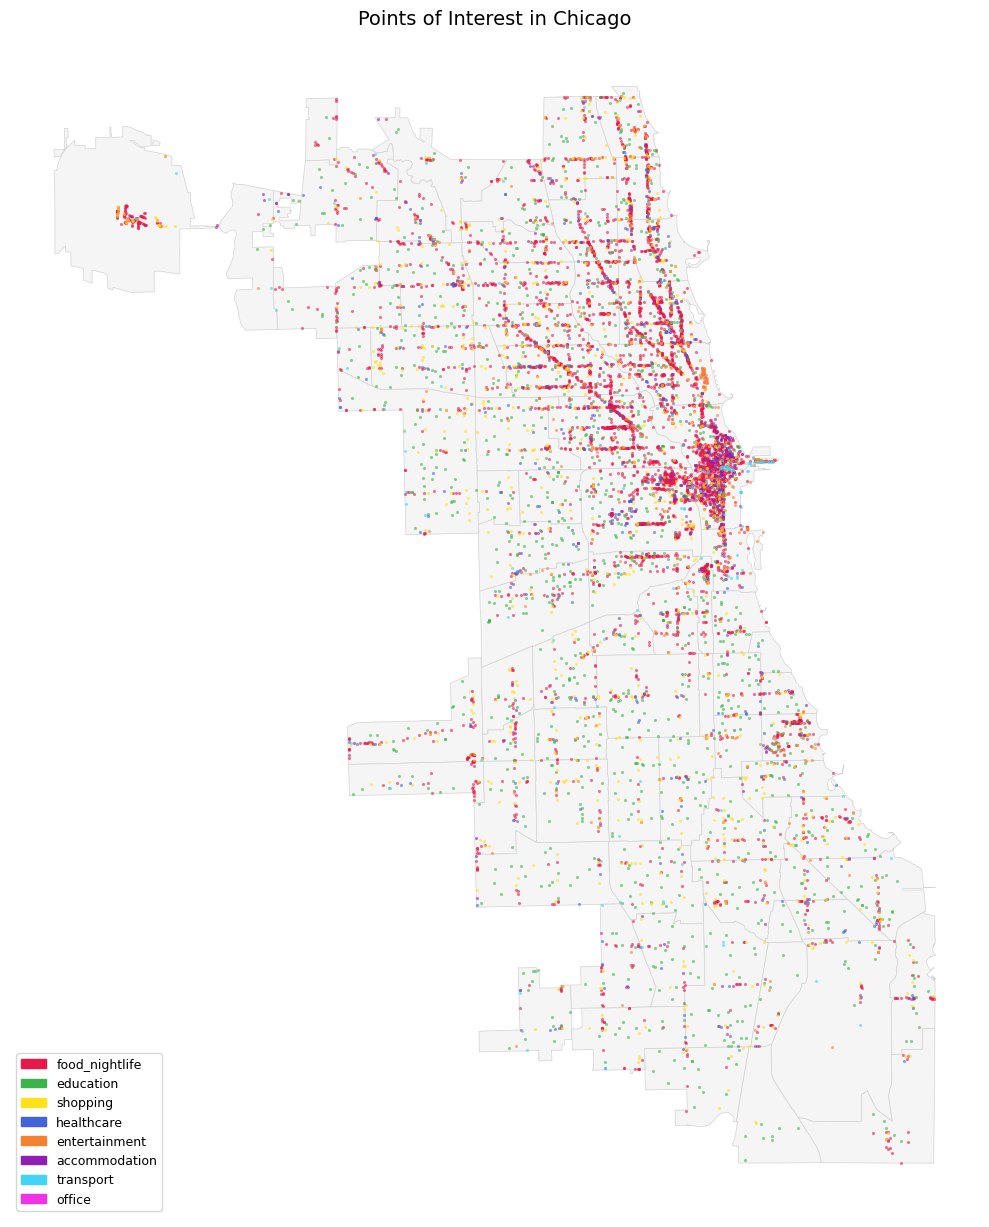

In [7]:
ca_gdf = gpd.read_file(Path("..") / "data" / "raw" / "community_areas.geojson")

category_colors = {
    "food_nightlife":  "#e6194b",
    "education":       "#3cb44b",
    "shopping":        "#ffe119",
    "healthcare":      "#4363d8",
    "entertainment":   "#f58231",
    "accommodation":   "#911eb4",
    "transport":       "#42d4f4",
    "office":          "#f032e6",
}

fig, ax = plt.subplots(figsize=(10, 14))
ca_gdf.plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.5)

for cat, color in category_colors.items():
    subset = pois[pois["category"] == cat]
    ax.scatter(
        subset["geometry"].x,
        subset["geometry"].y,
        c=color, s=5, alpha=0.6, linewidths=0, label=cat,
    )

ax.legend(
    handles=[mpatches.Patch(color=v, label=k) for k, v in category_colors.items()],
    loc="lower left", fontsize=9, framealpha=0.8,
)
ax.set_title("Points of Interest in Chicago", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [8]:
# ── 5. ASSIGN H3 HEX IDs ─────────────────────────────────────────────────────
# Use the same resolution as your trip data!
H3_RESOLUTION = 8  # adjust to match your trips

def point_to_h3(geom, resolution):
    return h3.latlng_to_cell(geom.y, geom.x, resolution)

pois["hex_id"] = pois["geometry"].apply(lambda g: point_to_h3(g, H3_RESOLUTION))

# ── 6. AGGREGATE: POI COUNTS PER HEX ─────────────────────────────────────────
poi_features = (
    pois
    .groupby(["hex_id", "category"])
    .size()
    .unstack(fill_value=0)
    .add_prefix("n_poi_")
    .reset_index()
)

print(poi_features.shape)
display(poi_features)

(734, 8)


category,hex_id,n_poi_accommodation,n_poi_education,n_poi_entertainment,n_poi_food_nightlife,n_poi_healthcare,n_poi_shopping,n_poi_transport
0,8826641917fffff,0,2,0,2,0,0,0
1,8826641939fffff,0,1,0,0,0,0,0
2,882664193bfffff,0,2,0,7,0,2,0
3,8826641943fffff,0,2,0,0,0,0,0
4,8826641945fffff,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...
729,88275936d3fffff,0,3,0,7,0,1,0
730,88275936d5fffff,0,1,0,4,0,0,0
731,88275936d7fffff,0,0,0,3,0,1,0
732,88275936dbfffff,0,0,0,1,0,0,1


## Loading POI Data in Subsequent Notebooks

The fetch and transformation steps above are encapsulated in `scripts/helpers/datasets.py` so that later notebooks can obtain the clean POI GeoDataFrame in a single call:

- **`scripts/helpers/datasets.py`** — `load_poi_data()` fetches the four OSM tag types, converts all geometries to points, applies the category mapping, and drops unmapped POIs.

Usage in any subsequent notebook:

```python
from scripts.helpers.datasets import load_poi_data

pois = load_poi_data()  # GeoDataFrame with columns: geometry, poi_type, category
```